# CNASim Benchmark

This notebook analyses the results of the experiments.

In [1]:
import os

import scgenome.plotting as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import anndata
from Bio import Phylo
from io import StringIO
import pandas as pd

from cellmates.utils.tree_utils import make_gt_tree_dist

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
# input = snakemake.input[0]
input = "../../results/statsC_F.csv"

In [62]:
stats_df_full = pd.read_csv(input).drop_duplicates(subset=['dataset', 'seed', 'data_type'])
# stats_df['noise'] = stats_df['dataset'].map(lambda x: x[-1])
stats_df_full.describe()

,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,uw_mse,rf,urf,nrf,f1_gt,f1_em,cn_mad
count,78.000000,78.0,78.0,78.000000,78.0,78.000000,78.000000,7.800000e+01,7.800000e+01,78.000000,78.000000,78.000000,78.000000,78.000000,0.0
mean,1.000000,50.0,7.0,1.743590,2000.0,2.846154,0.000017,3.763572e-06,8.900928e-06,2.275953,20.076923,0.209135,0.982122,0.981036,NaN
std,0.821781,0.0,0.0,1.761315,0.0,2.227787,0.000024,1.295017e-05,2.883701e-05,3.007128,11.783512,0.122745,0.051651,0.059476,NaN
min,0.000000,50.0,7.0,1.000000,2000.0,2.000000,0.000001,5.900472e-08,5.113584e-08,0.015409,2.000000,0.020833,0.778564,0.599406,NaN
25%,0.000000,50.0,7.0,1.000000,2000.0,2.000000,0.000007,1.621289e-07,3.653671e-07,0.030922,12.000000,0.125000,1.000000,1.000000,NaN
50%,1.000000,50.0,7.0,1.000000,2000.0,2.000000,0.000009,2.882063e-07,6.283419e-07,2.016963,16.000000,0.166667,1.000000,1.000000,NaN
75%,2.000000,50.0,7.0,1.000000,2000.0,2.000000,0.000012,7.712231e-07,1.731536e-06,3.018751,24.000000,0.250000,1.000000,1.000000,NaN
max,2.000000,50.0,7.0,6.000000,2000.0,10.000000,0.000135,8.534048e-05,1.670362e-04,19.053997,52.000000,0.541667,1.000000,1.000000,NaN


In [63]:
stats_df_full.head()

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,uw_mse,rf,urf,nrf,f1_gt,f1_em,wgd,gt_ties,data_type,cn_mad
0,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,2,50,7,1,2000,2.0,0.000009,5.900472e-08,6.604534e-07,0.015409,12,0.125000,1.0,1.0,False,True,reads,NaN
1,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,2,50,7,1,2000,2.0,0.000008,1.245313e-07,1.110481e-06,0.019027,10,0.104167,1.0,1.0,False,True,cn,NaN
2,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,1,50,7,1,2000,2.0,0.000012,8.005009e-08,8.985666e-08,0.020112,20,0.208333,1.0,1.0,False,True,reads,NaN
3,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,1,50,7,1,2000,2.0,0.000009,2.707924e-07,3.531073e-07,1.018950,22,0.229167,1.0,1.0,False,True,cn,NaN
4,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,0,50,7,1,2000,2.0,0.000003,1.081550e-06,2.629705e-06,8.025889,24,0.250000,1.0,1.0,False,True,reads,NaN


In [7]:
local_data_path = "/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results"

## C dataset - WGD and Clones

```
Cs:
  variable: [wgd, n_clones, founder_chrom_rate, clone_chrom_rate, chrom_arm_rate]
  values:
    - [false, 4, 2, 2, 0]
    - [true, 4, 2, 2, 0.75]
```


In [65]:
stats_df = stats_df_full[stats_df_full['dataset'].apply(lambda x: x.startswith('Cs'))]
stats_df

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,uw_mse,rf,urf,nrf,f1_gt,f1_em,wgd,gt_ties,data_type,cn_mad
468,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs1_0,2,50,7,5,2000,2.0,0.000006,2.918376e-07,5.152772e-07,2.019319,36,0.375000,0.899921,0.949469,False,True,reads,NaN
469,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs1_0,2,50,7,5,2000,2.0,0.000006,2.795121e-07,6.432755e-07,3.018810,24,0.250000,0.899921,0.955921,False,True,cn,NaN
470,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs1_0,1,50,7,6,2000,2.0,0.000013,1.017311e-07,5.057369e-07,2.027090,42,0.437500,0.969577,0.914021,False,True,reads,NaN
471,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs1_0,1,50,7,6,2000,2.0,0.000010,2.989506e-07,5.196832e-07,7.018254,14,0.145833,0.969577,0.914021,False,True,cn,NaN
472,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs1_0,0,50,7,6,2000,2.0,0.000008,4.324610e-07,3.138744e-06,0.022883,34,0.354167,0.920761,0.920761,False,True,reads,NaN
473,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs1_0,0,50,7,6,2000,2.0,0.000005,4.004889e-07,1.738160e-06,2.019431,24,0.250000,0.920761,0.920761,False,True,cn,NaN
2808,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs2_0,2,50,7,6,2000,2.0,0.000001,9.780573e-07,3.235243e-06,3.032936,46,0.479167,0.784722,0.814888,True,True,reads,NaN
2809,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs2_0,2,50,7,6,2000,2.0,0.000003,3.566282e-07,1.300141e-06,8.020851,20,0.208333,0.784722,0.863277,True,True,cn,NaN
2810,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs2_0,1,50,7,6,2000,2.0,0.000010,2.845751e-07,1.070370e-06,0.027535,28,0.291667,0.949206,0.940502,True,True,reads,NaN
2811,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Cs2_0,1,50,7,6,2000,2.0,0.000007,7.612644e-07,1.748916e-06,3.024240,16,0.166667,0.949206,0.949206,True,True,cn,NaN


### Small tree
#### Data

In [16]:
# plot example
dat_dir = os.path.join(local_data_path, "Cs1_0", "0")
adata = anndata.read_h5ad(os.path.join(dat_dir, "anndata.h5ad"))
adata = adata[~adata.obs['normal']].copy()
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
# use tree from cn-derived branch lengths
cell_names = adata.obs_names.tolist()
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')

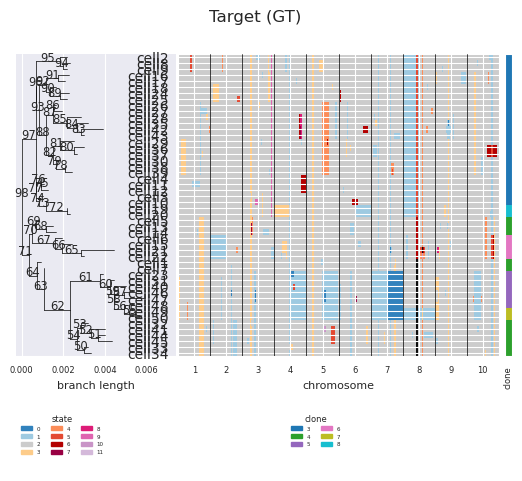

In [17]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'], show_cell_ids=True)
g['fig'].suptitle('Target (GT)');

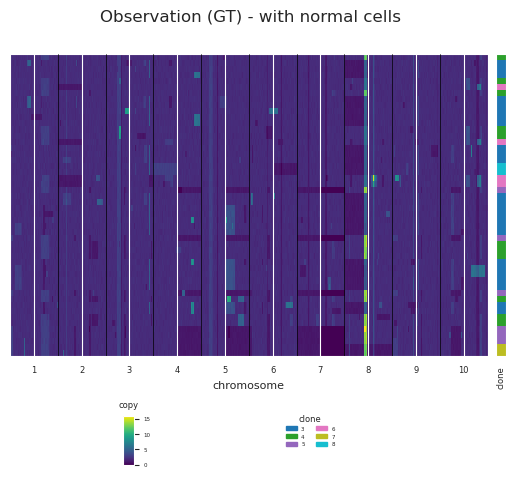

In [18]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', annotation_fields=['clone'], raw=True)
g['fig'].suptitle('Observation (GT) - with normal cells');

#### Inferred

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


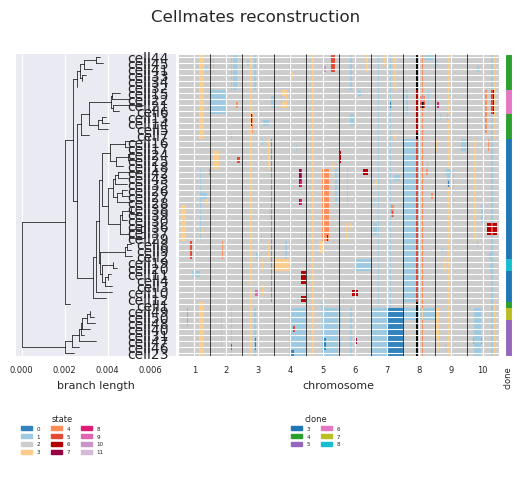

In [20]:
em_nwk = open(os.path.join(dat_dir, "cm_out", "tree.nwk")).read()
inferred_tree = Phylo.read(os.path.join(dat_dir, "cm_out", "tree.nwk"), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'], show_cell_ids=True)
g['fig'].suptitle('Cellmates reconstruction');

## Robinson Fould

In [53]:
# place rf, urf, nrf in same col 'metric'
rf_melt = pd.melt(stats_df,
                  id_vars=['wgd', 'data_type'],
                  value_vars=['rf', 'urf', 'nrf'],
                  var_name='metric',
                  value_name='value'
                  )
rf_melt.head()

,wgd,data_type,metric,value
0,False,reads,rf,0.015409
1,False,cn,rf,0.019027
2,False,reads,rf,0.020112
3,False,cn,rf,1.018950
4,False,reads,rf,8.025889


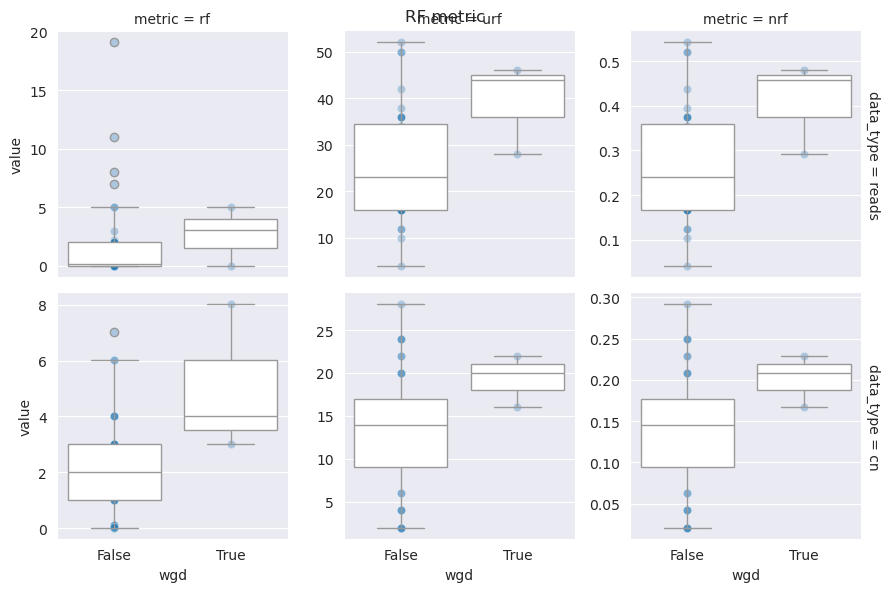

In [54]:
# plot RF distance
g = sns.FacetGrid(rf_melt, row='data_type', col='metric', margin_titles=True, sharey=False)
g.map_dataframe(sns.boxplot, x='wgd', y='value', color='white')
g.map_dataframe(sns.scatterplot, x='wgd', y='value',
                alpha=0.3, legend=False)
g.fig.suptitle('RF metric');

kk## F1 metric (against GT)

In [55]:
f1_melt = pd.melt(stats_df,
                  id_vars=['seed', 'data_type', 'wgd'],
                  value_vars=['f1_gt', 'f1_em'],
                  var_name='metric',
                  value_name='value'
                  )
f1_melt.head()


,seed,data_type,wgd,metric,value
0,2,reads,False,f1_gt,1.0
1,2,cn,False,f1_gt,1.0
2,1,reads,False,f1_gt,1.0
3,1,cn,False,f1_gt,1.0
4,0,reads,False,f1_gt,1.0


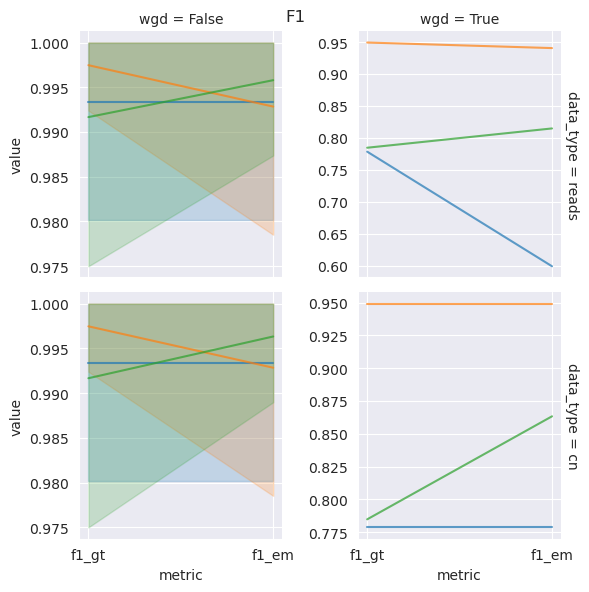

In [57]:
g = sns.FacetGrid(f1_melt, row='data_type', col='wgd', margin_titles=True, sharey=False, hue='seed')
g.map(sns.lineplot, 'metric', 'value', alpha=0.7, markers=True)
g.fig.suptitle('F1');


## Branch lengths error

In [58]:
err_melt = pd.melt(stats_df,
                  id_vars=['data_type', 'wgd'],
                  value_vars=['ru_mse', 'uv_mse', 'uw_mse'],
                  var_name='metric',
                  value_name='value'
                  )
err_melt.head()

,data_type,wgd,metric,value
0,reads,False,ru_mse,0.000009
1,cn,False,ru_mse,0.000008
2,reads,False,ru_mse,0.000012
3,cn,False,ru_mse,0.000009
4,reads,False,ru_mse,0.000003


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


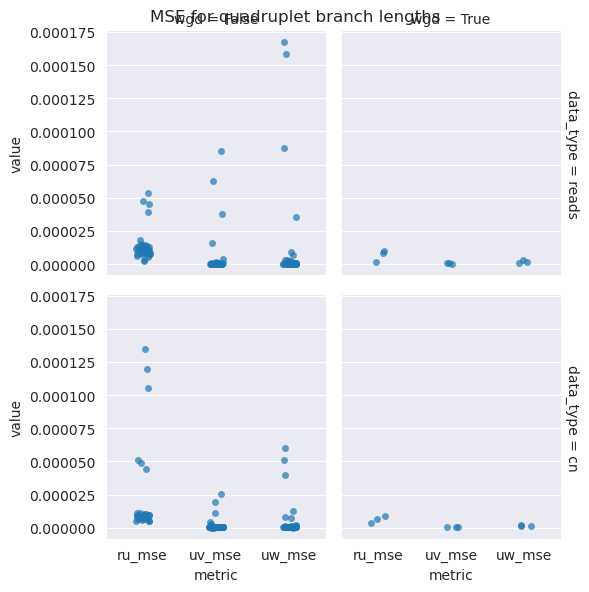

In [61]:
g = sns.FacetGrid(err_melt, row='data_type', col='wgd', margin_titles=True, sharey=True)
g.map(sns.stripplot, 'metric', 'value', alpha=0.7, dodge=True)
g.fig.suptitle('MSE for quadruplet branch lengths');

## D dataset - CNAs per edge

```
Ds:
  variable: mean_cnas_per_edge
  values: [2, 5, 10]
```


In [108]:
stats_df = stats_df_full[stats_df_full['dataset'].apply(lambda x: x.startswith('Ds'))]

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,uw_mse,rf,urf,nrf,f1_gt,f1_em,wgd,gt_ties,data_type,cn_mad
936,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds3_0,2,50,7,1,2000,10.0,0.000018,8.534048e-05,1.670362e-04,2.176889,50,0.520833,1.0,1.0,False,False,reads,NaN
937,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds3_0,2,50,7,1,2000,10.0,0.000120,1.902818e-05,5.138749e-05,0.115243,2,0.020833,1.0,1.0,False,False,cn,NaN
938,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds3_0,1,50,7,1,2000,10.0,0.000040,6.226348e-05,8.720579e-05,0.181562,52,0.541667,1.0,1.0,False,False,reads,NaN
939,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds3_0,1,50,7,1,2000,10.0,0.000105,2.523293e-05,3.987351e-05,0.110208,2,0.020833,1.0,1.0,False,False,cn,NaN
940,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds3_0,0,50,7,1,2000,10.0,0.000045,3.768867e-05,1.583670e-04,0.183721,50,0.520833,1.0,1.0,False,False,reads,NaN
941,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds3_0,0,50,7,1,2000,10.0,0.000135,1.094502e-05,6.033837e-05,0.106200,4,0.041667,1.0,1.0,False,False,cn,NaN
1872,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds2_0,2,50,7,1,2000,5.0,0.000047,3.951225e-06,8.944745e-06,0.064865,36,0.375000,1.0,1.0,False,False,reads,NaN
1873,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds2_0,2,50,7,1,2000,5.0,0.000044,2.482019e-06,7.448244e-06,0.050809,2,0.020833,1.0,1.0,False,False,cn,NaN
1874,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds2_0,1,50,7,1,2000,5.0,0.000008,1.617336e-05,3.567241e-05,19.053997,26,0.270833,1.0,1.0,False,True,reads,NaN
1875,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds2_0,1,50,7,1,2000,5.0,0.000051,4.090142e-06,1.264188e-05,1.059195,4,0.041667,1.0,1.0,False,True,cn,NaN


j### Small tree
#### Data

In [109]:
# plot example
dat_dir = os.path.join(local_data_path, "Ds3_0", "0")
adata = anndata.read_h5ad(os.path.join(dat_dir, "anndata.h5ad"))
adata = adata[~adata.obs['normal']].copy()
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
# use tree from cn-derived branch lengths
cell_names = adata.obs_names.tolist()
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')

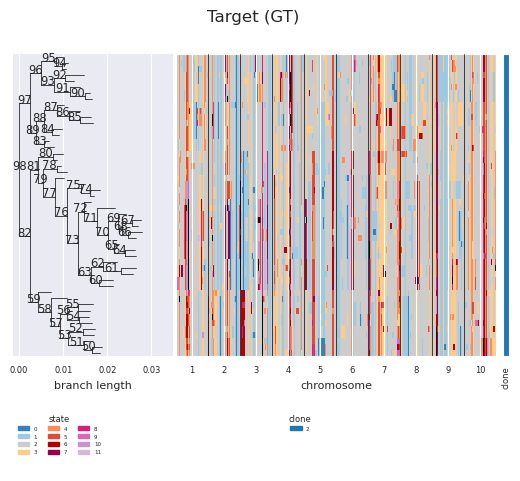

In [110]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'])
g['fig'].suptitle('Target (GT)');

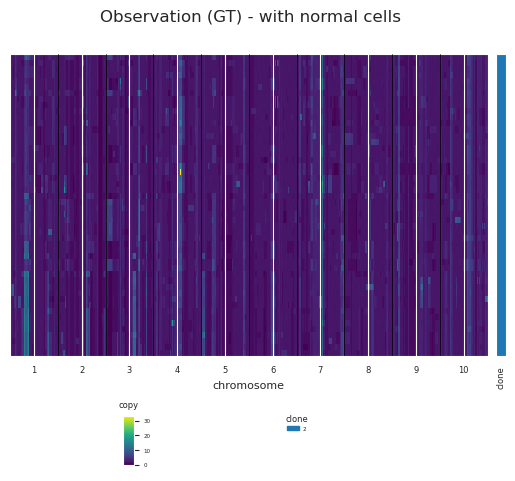

In [111]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', annotation_fields=['clone'], raw=True)
g['fig'].suptitle('Observation (GT) - with normal cells');

#### Inferred

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


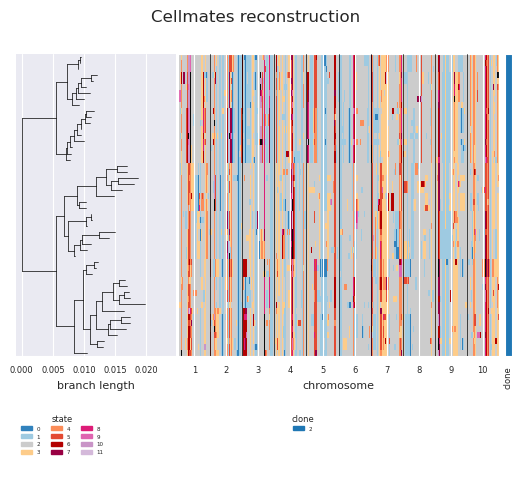

In [112]:
em_nwk = open(os.path.join(dat_dir, "cm_out", "tree.nwk")).read()
inferred_tree = Phylo.read(os.path.join(dat_dir, "cm_out", "tree.nwk"), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'])
g['fig'].suptitle('Cellmates reconstruction');

## Robinson Fould

In [113]:
# place rf, urf, nrf in same col 'metric'
levels = ['2', '5', '10']
stats_df['cna_rate'] = stats_df['dataset'].map(lambda x: levels[int(x.split('_')[0][-1])-1]).astype('category').cat.set_categories(levels)
stats_df['cna_rate'].value_counts()

/tmp/ipykernel_2739385/477026849.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_df['cna_rate'] = stats_df['dataset'].map(lambda x: levels[int(x.split('_')[0][-1])-1]).astype('category').cat.set_categories(levels)


cna_rate
2     6
5     6
10    6
Name: count, dtype: int64

In [114]:
rf_melt = pd.melt(stats_df,
                  id_vars=['cna_rate', 'data_type'],
                  value_vars=['rf', 'urf', 'nrf'],
                  var_name='metric',
                  value_name='value'
                  )
rf_melt.head()

,cna_rate,data_type,metric,value
0,10,reads,rf,2.176889
1,10,cn,rf,0.115243
2,10,reads,rf,0.181562
3,10,cn,rf,0.110208
4,10,reads,rf,0.183721


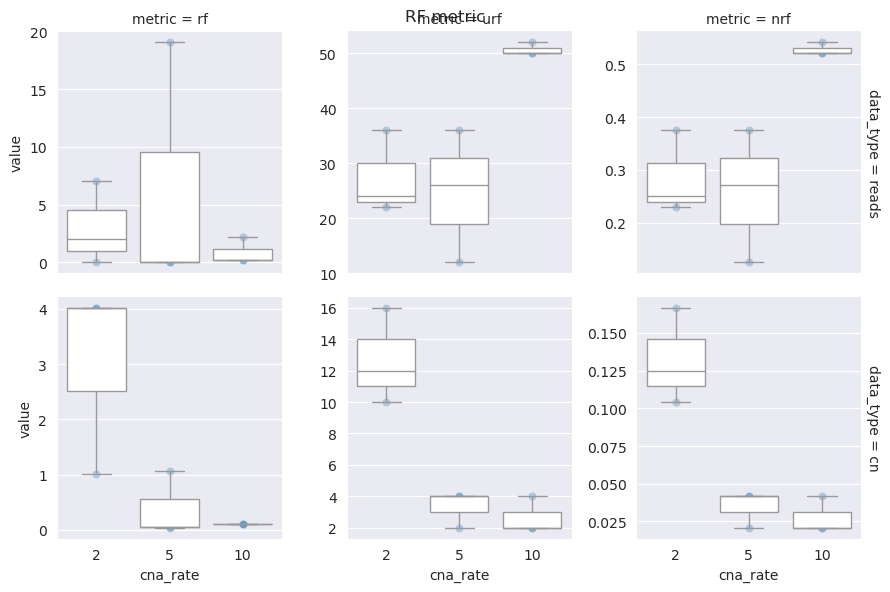

In [115]:
# plot RF distance
g = sns.FacetGrid(rf_melt, row='data_type', col='metric', margin_titles=True, sharey=False)
g.map_dataframe(sns.boxplot, x='cna_rate', y='value', color='white')
g.map_dataframe(sns.scatterplot, x='cna_rate', y='value',
                alpha=0.3, legend=False)
g.fig.suptitle('RF metric');

## Branch lengths error

In [116]:
err_melt = pd.melt(stats_df,
                  id_vars=['data_type', 'cna_rate'],
                  value_vars=['ru_mse', 'uv_mse', 'uw_mse'],
                  var_name='metric',
                  value_name='value'
                  )
err_melt.head()

,data_type,cna_rate,metric,value
0,reads,10,ru_mse,0.000018
1,cn,10,ru_mse,0.000120
2,reads,10,ru_mse,0.000040
3,cn,10,ru_mse,0.000105
4,reads,10,ru_mse,0.000045


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


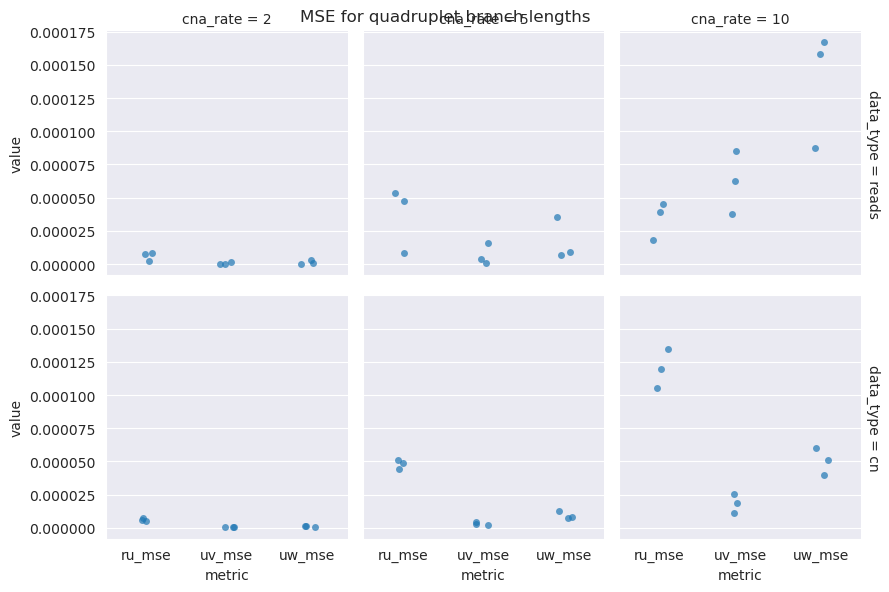

In [117]:
g = sns.FacetGrid(err_melt, row='data_type', col='cna_rate', margin_titles=True, sharey=True)
g.map(sns.stripplot, 'metric', 'value', alpha=0.7, dodge=True)
g.fig.suptitle('MSE for quadruplet branch lengths');

## F dataset - noise (coverage)

```
Fs:
  variable: [boundary_noise, jitter, coverage]
  values:
    - [0.05, 0.02, 0.2]
    - [0.15, 0.02, 0.2]
    - [0.05, 0.04, 0.1]
    - [0.15, 0.04, 0.1]
    - [0.05, 0.06, 0.08]
    - [0.15, 0.06, 0.08]
    - [0.05, 0.10, 0.05]
    - [0.15, 0.10, 0.05]
```


In [118]:
stats_df = stats_df_full[stats_df_full['dataset'].apply(lambda x: x.startswith('Fs'))]
stats_df

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,uw_mse,rf,urf,nrf,f1_gt,f1_em,wgd,gt_ties,data_type,cn_mad
0,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,2,50,7,1,2000,2.0,0.000009,5.900472e-08,6.604534e-07,0.015409,12,0.125000,1.0,1.0,False,True,reads,NaN
1,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,2,50,7,1,2000,2.0,0.000008,1.245313e-07,1.110481e-06,0.019027,10,0.104167,1.0,1.0,False,True,cn,NaN
2,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,1,50,7,1,2000,2.0,0.000012,8.005009e-08,8.985666e-08,0.020112,20,0.208333,1.0,1.0,False,True,reads,NaN
3,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,1,50,7,1,2000,2.0,0.000009,2.707924e-07,3.531073e-07,1.018950,22,0.229167,1.0,1.0,False,True,cn,NaN
4,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,0,50,7,1,2000,2.0,0.000003,1.081550e-06,2.629705e-06,8.025889,24,0.250000,1.0,1.0,False,True,reads,NaN
5,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs2_0,0,50,7,1,2000,2.0,0.000007,3.593266e-07,7.215991e-07,2.019619,16,0.166667,1.0,1.0,False,True,cn,NaN
234,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs5_0,2,50,7,1,2000,2.0,0.000011,7.868426e-08,7.131042e-08,0.019223,4,0.041667,1.0,1.0,False,True,reads,NaN
235,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs5_0,2,50,7,1,2000,2.0,0.000009,3.333744e-07,4.333748e-07,4.015462,2,0.020833,1.0,1.0,False,True,cn,NaN
236,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs5_0,1,50,7,1,2000,2.0,0.000011,1.793211e-07,3.653599e-07,0.020144,10,0.104167,1.0,1.0,False,True,reads,NaN
237,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs5_0,1,50,7,1,2000,2.0,0.000008,4.206284e-07,7.387954e-07,1.019758,6,0.062500,1.0,1.0,False,True,cn,NaN


### Small tree
#### Data

In [119]:
# plot example
dat_dir = os.path.join(local_data_path, "Fs8_0", "0")
adata = anndata.read_h5ad(os.path.join(dat_dir, "anndata.h5ad"))
adata = adata[~adata.obs['normal']].copy()
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
# use tree from cn-derived branch lengths
cell_names = adata.obs_names.tolist()
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')

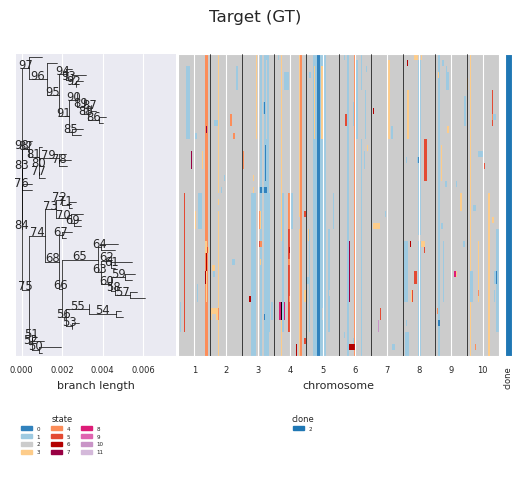

In [120]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'])
g['fig'].suptitle('Target (GT)');

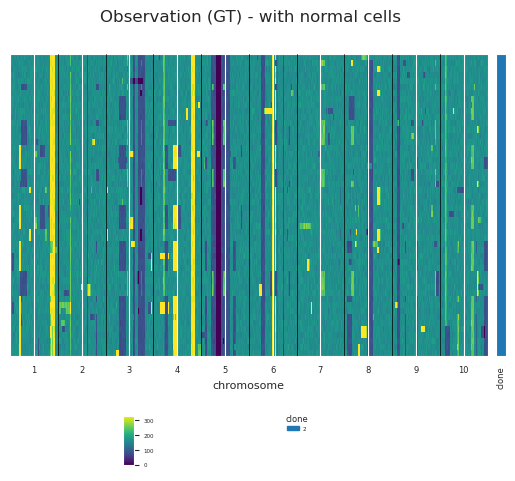

In [121]:
perc_98 = np.nanpercentile(adata.X, 98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name=None, annotation_fields=['clone'], raw=True, vmax=perc_98)
g['fig'].suptitle('Observation (GT) - with normal cells');

#### Inferred

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


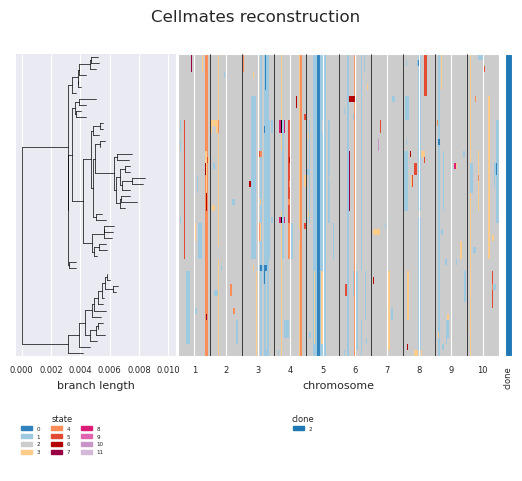

In [122]:
em_nwk = open(os.path.join(dat_dir, "cm_out", "tree.nwk")).read()
inferred_tree = Phylo.read(os.path.join(dat_dir, "cm_out", "tree.nwk"), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'])
g['fig'].suptitle('Cellmates reconstruction');

## Robinson Fould

In [123]:
levels = [str(i) for i in [0.2, 0.1, 0.08, 0.05]]
# place rf, urf, nrf in same col 'metric'
stats_df['coverage'] = stats_df['dataset'].map(lambda x: levels[(int(x.split('_')[0][-1])-1)//2]).astype('category').cat.set_categories(levels, ordered=True)
stats_df['coverage'].value_counts()

/tmp/ipykernel_2739385/166766539.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_df['coverage'] = stats_df['dataset'].map(lambda x: levels[(int(x.split('_')[0][-1])-1)//2]).astype('category').cat.set_categories(levels, ordered=True)


coverage
0.2     12
0.1     12
0.08    12
0.05    12
Name: count, dtype: int64

In [124]:
rf_melt = pd.melt(stats_df,
                  id_vars=['coverage', 'data_type'],
                  value_vars=['rf', 'urf', 'nrf'],
                  var_name='metric',
                  value_name='value'
                  )
rf_melt.head()

,coverage,data_type,metric,value
0,0.2,reads,rf,0.015409
1,0.2,cn,rf,0.019027
2,0.2,reads,rf,0.020112
3,0.2,cn,rf,1.018950
4,0.2,reads,rf,8.025889


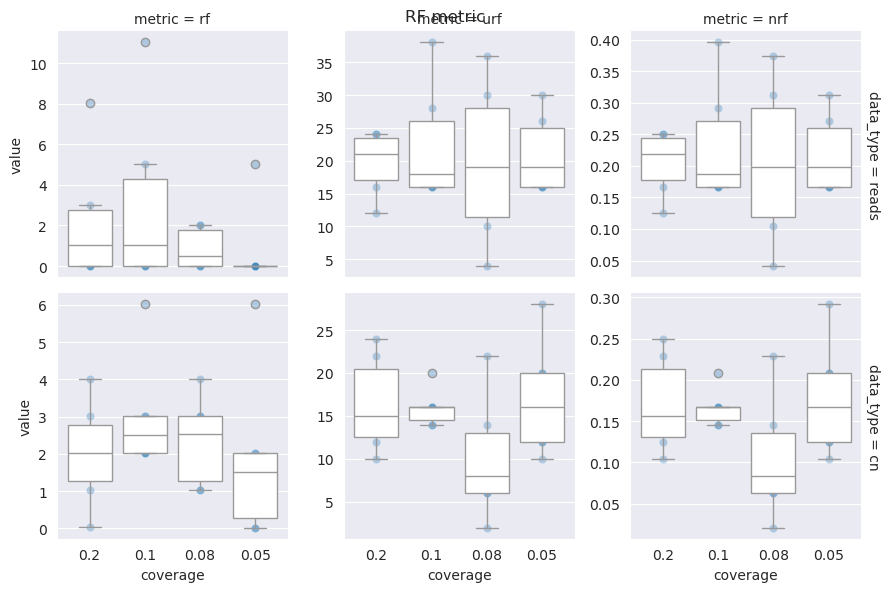

In [130]:
# plot RF distance
g = sns.FacetGrid(rf_melt, row='data_type', col='metric', margin_titles=True, sharey=False)
g.map_dataframe(sns.boxplot, x='coverage', y='value', color='white')
g.map_dataframe(sns.scatterplot, x='coverage', y='value',
                alpha=0.3, legend=False)
g.figure.suptitle('RF metric');

## Branch lengths error

In [127]:
err_melt = pd.melt(stats_df,
                  id_vars=['data_type', 'coverage'],
                  value_vars=['ru_mse', 'uv_mse', 'uw_mse'],
                  var_name='metric',
                  value_name='value'
                  )
err_melt.head()

,data_type,coverage,metric,value
0,reads,0.2,ru_mse,0.000009
1,cn,0.2,ru_mse,0.000008
2,reads,0.2,ru_mse,0.000012
3,cn,0.2,ru_mse,0.000009
4,reads,0.2,ru_mse,0.000003


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


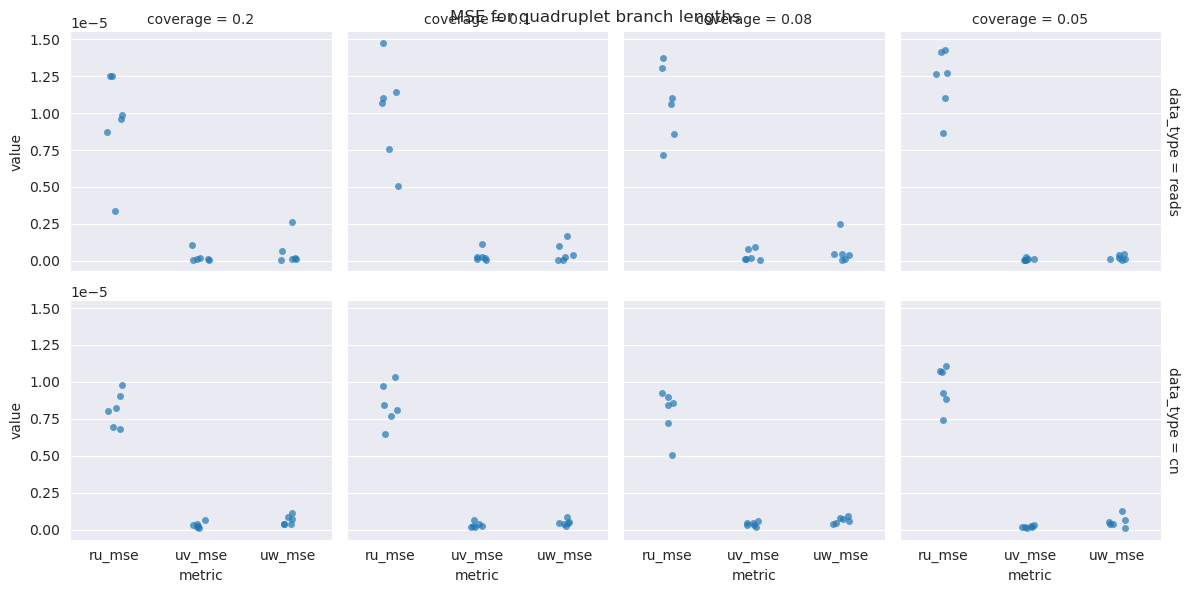

In [129]:
g = sns.FacetGrid(err_melt, row='data_type', col='coverage', margin_titles=True, sharey=True)
g.map(sns.stripplot, 'metric', 'value', alpha=0.7, dodge=True)
g.fig.suptitle('MSE for quadruplet branch lengths');